## Load Dataset and Basic Information

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [2]:
df = pd.read_csv("crop_classification_final_dataset.csv")

In [3]:
X = df.drop("Crop_Type", axis=1)
y = df["Crop_Type"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (13, 14)
Target Shape: (13,)


In [4]:
print(df.select_dtypes(include=['object']).columns)

Index(['DISTRICT', 'Crop_Type'], dtype='str')


C:\Users\SWIFT GO14\AppData\Local\Temp\ipykernel_31592\845905018.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.select_dtypes(include=['object']).columns)


## Feature and Target Selection

In [5]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in X.select_dtypes(include=['object']).columns:
    X[col] = le.fit_transform(X[col])

C:\Users\SWIFT GO14\AppData\Local\Temp\ipykernel_31592\3360220096.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in X.select_dtypes(include=['object']).columns:


## Feature Scaling 

In [6]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

## Split the Dataset

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (10, 14)
Testing Data: (3, 14)


## Neural Network Model Building

In [8]:
model = MLPClassifier(
    hidden_layer_sizes=(100,),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    max_iter=500,
    random_state=42
)

model.fit(X_train, y_train)

,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",500
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(100,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


## Predictions

In [9]:
y_pred = model.predict(X_test)

## Training Loss

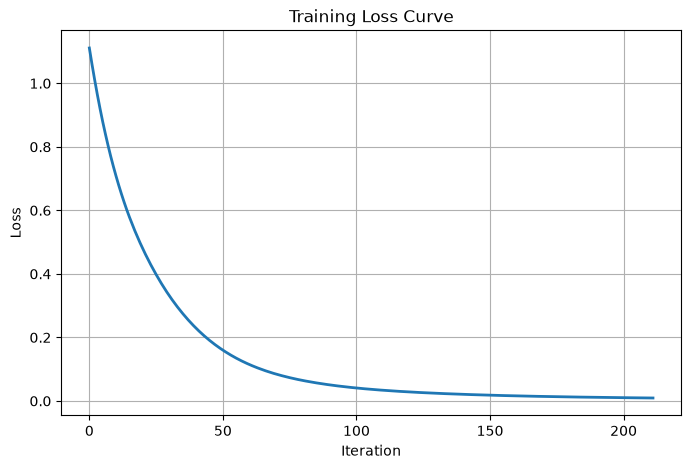

In [10]:


from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

train_pred = model.predict(X_train)


# Plot Training Loss
plt.figure(figsize=(8,5))
plt.plot(model.loss_curve_, linewidth=2)
plt.title("Training Loss Curve")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

##  Evaluate the model

In [11]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.6666666666666666
Precision: 0.5
Recall   : 0.6666666666666666
F1 Score : 0.5555555555555555


c:\Users\SWIFT GO14\anaconda3\envs\tensorflow_env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## Confusion Matrix

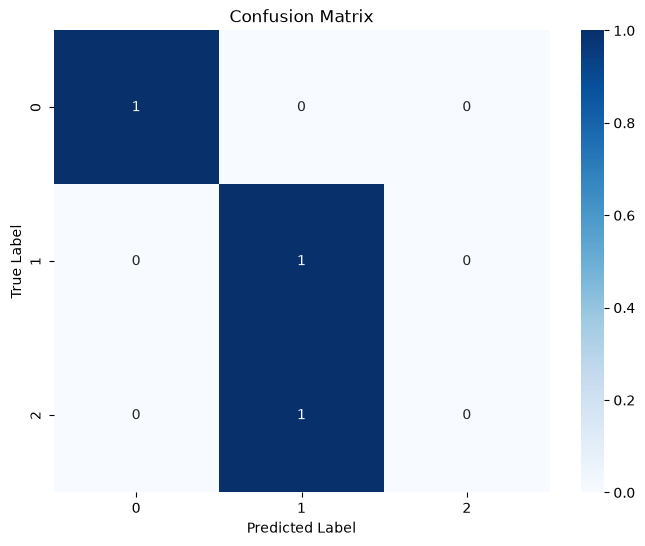

In [12]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

## Hyperparameter Tuning

In [13]:
model1 = MLPClassifier(
    hidden_layer_sizes=(50,),
    activation='relu',
    max_iter=500,
    random_state=42
)

model1.fit(X_train, y_train)

pred1 = model1.predict(X_test)

print("Model 1 Accuracy:", accuracy_score(y_test, pred1))

Model 1 Accuracy: 0.0


In [14]:
model2 = MLPClassifier(
    hidden_layer_sizes=(100,),
    activation='relu',
    max_iter=500,
    random_state=42
)

model2.fit(X_train, y_train)

pred2 = model2.predict(X_test)

print("Model 2 Accuracy:", accuracy_score(y_test, pred2))

Model 2 Accuracy: 0.6666666666666666


In [15]:
model3 = MLPClassifier(
    hidden_layer_sizes=(100,50),
    activation='relu',
    max_iter=500,
    random_state=42
)

model3.fit(X_train, y_train)

pred3 = model3.predict(X_test)

print("Model 3 Accuracy:", accuracy_score(y_test, pred3))

Model 3 Accuracy: 0.3333333333333333


In [16]:
model4 = MLPClassifier(
    hidden_layer_sizes=(150,100),
    activation='tanh',
    max_iter=700,
    random_state=42
)

model4.fit(X_train, y_train)

pred4 = model4.predict(X_test)

print("Model 4 Accuracy:", accuracy_score(y_test, pred4))

Model 4 Accuracy: 0.6666666666666666


## Compare Hyperparameters

In [17]:
results = pd.DataFrame({
    "Model": ["Model 1", "Model 2", "Model 3", "Model 4"],
    "Hidden Layers": ["(50,)", "(100,)", "(100,50)", "(150,100)"],
    "Activation": ["ReLU", "ReLU", "ReLU", "Tanh"],
    "Iterations": [500, 500, 500, 700],
    "Accuracy": [
        accuracy_score(y_test, pred1),
        accuracy_score(y_test, pred2),
        accuracy_score(y_test, pred3),
        accuracy_score(y_test, pred4)
    ]
})

results

,Model,Hidden Layers,Activation,Iterations,Accuracy
0,Model 1,"(50,)",ReLU,500,0.000000
1,Model 2,"(100,)",ReLU,500,0.666667
2,Model 3,"(100,50)",ReLU,500,0.333333
3,Model 4,"(150,100)",Tanh,700,0.666667


In [18]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       Maize       1.00      1.00      1.00         1
       Paddy       0.50      1.00      0.67         1
       Wheat       0.00      0.00      0.00         1

    accuracy                           0.67         3
   macro avg       0.50      0.67      0.56         3
weighted avg       0.50      0.67      0.56         3



c:\Users\SWIFT GO14\anaconda3\envs\tensorflow_env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\SWIFT GO14\anaconda3\envs\tensorflow_env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\SWIFT GO14\anaconda3\envs\tensorflow_env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier,